In [ ]:
import os
os.chdir(Insert Project Path)

## Notebook 3: EDA
Now, I began to analyse the data for trends, correlation and to investigate what features would be useful for contributing towards ranking close approach events by risk. I defined my *risk score* as an event-level score designed to represent the combination of characteristics associated with greater asteroid close-approach risk. The aim was not to replicate NASA's classfication of a hazardous event.

In [2]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading SQL into pandas df
with sqlite3.connect("data/nasa_asteroids.db") as c:

    df = pd.read_sql_query("""
        SELECT *
        FROM close_approaches
        """, c
    )

In [4]:
#ensuring data loaded correctly
print(df.shape)
df.head()

(14471, 13)


,event_id,asteroid_id,name,absolute_magnitude_h,diameter_min_km,diameter_max_km,is_potentially_hazardous,is_sentry_object,close_approach_date,close_approach_date_full,relative_velocity_km_s,miss_distance_au,orbiting_body
0,3564720_2020-Jan-01 21:59,3564720,(2011 HS60),21.34,0.143402,0.320656,0,0,2020-01-01,2020-01-01 21:59,17.774429,0.198878,Earth
1,3591759_2020-Jan-01 11:55,3591759,(2011 YE40),25.20,0.024241,0.054205,0,0,2020-01-01,2020-01-01 11:55,12.780287,0.061832,Earth
2,3630817_2020-Jan-01 03:23,3630817,(2013 EC20),29.00,0.004213,0.009420,0,1,2020-01-01,2020-01-01 03:23,2.793701,0.162019,Earth
3,3747497_2020-Jan-01 08:44,3747497,(2016 EF195),25.50,0.021113,0.047211,0,0,2020-01-01,2020-01-01 08:44,17.548446,0.276326,Earth
4,3893737_2020-Jan-01 14:55,3893737,(2019 WE5),23.30,0.058151,0.130029,0,0,2020-01-01,2020-01-01 14:55,5.002825,0.134597,Earth


In [5]:
#checking validity and some stats
df.info()
df.describe().T
#most data validity checks are handled earlier on

<class 'pandas.DataFrame'>
RangeIndex: 14471 entries, 0 to 14470
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   event_id                  14471 non-null  str    
 1   asteroid_id               14471 non-null  str    
 2   name                      14471 non-null  str    
 3   absolute_magnitude_h      14471 non-null  float64
 4   diameter_min_km           14471 non-null  float64
 5   diameter_max_km           14471 non-null  float64
 6   is_potentially_hazardous  14471 non-null  int64  
 7   is_sentry_object          14471 non-null  int64  
 8   close_approach_date       14471 non-null  str    
 9   close_approach_date_full  14471 non-null  str    
 10  relative_velocity_km_s    14471 non-null  float64
 11  miss_distance_au          14471 non-null  float64
 12  orbiting_body             14471 non-null  str    
dtypes: float64(5), int64(2), str(6)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
absolute_magnitude_h,14471.0,23.573656,2.767551,10.400000,21.410000,23.700000,25.650000,32.560000
diameter_min_km,14471.0,0.112174,0.253890,0.000818,0.019704,0.048368,0.138853,22.108281
diameter_max_km,14471.0,0.250828,0.567715,0.001828,0.044060,0.108153,0.310485,49.435619
is_potentially_hazardous,14471.0,0.107525,0.309791,0.000000,0.000000,0.000000,0.000000,1.000000
is_sentry_object,14471.0,0.046991,0.211626,0.000000,0.000000,0.000000,0.000000,1.000000
relative_velocity_km_s,14471.0,13.735364,6.968060,0.080168,8.321646,12.908385,18.029074,57.546852
miss_distance_au,14471.0,0.263333,0.140451,0.000105,0.145061,0.263754,0.386790,0.499952


### Categorical EDA
I began by looking into the categorical features of the data. These were NASA's "*is_potentially_hazardous*","*is_sentry_object*" and "*orbiting_body*" classifications. The classification of a hazardous object by NASA is not useful in its own right, as I didn't want non-physical data about the asteroid to influence its risk score, but it would be useful and interesting to compare this to my results at the end. Additionally, whether or not an asteroid is tracked by NASA's Sentry system should not influence the program's calculation. Finally, although included, all asteroids are orbiting the Earth in this dataset so it is largely useless.

In [7]:
# firstly categorial EDA, note that iph and iso are likely to be omitted in risk score and ML, but need to investigate
categorical_features = ["is_potentially_hazardous", "is_sentry_object", "orbiting_body"]
for f in categorical_features:
    print(df[f].value_counts())
# can immediately conclude oribiting body wont be useful
categorical_features.remove("orbiting_body")

is_potentially_hazardous
0    12915
1     1556
Name: count, dtype: int64
is_sentry_object
0    13791
1      680
Name: count, dtype: int64
orbiting_body
Earth    14471
Name: count, dtype: int64


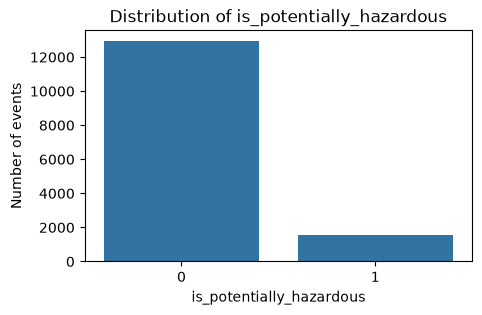

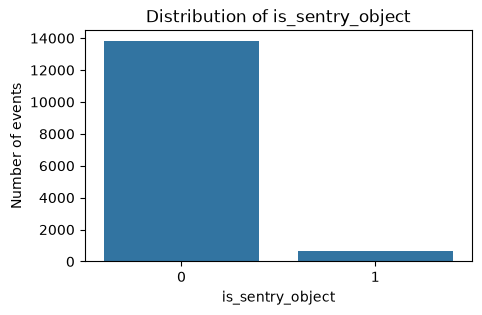

In [8]:
#count plots
for f in categorical_features:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=f)
    plt.title(f"Distribution of {f}")
    plt.xlabel(f)
    plt.ylabel("Number of events")
    plt.show()



I observed that these two features were largely dominated by "*FALSE*" readings (using a binary system due to SQLite). This is perhaps useful as it indicates to me that the majority of near-Earth objects NASA monitors are not high-risk.

### Continuous EDA
Then, I investigated the continuous, numerical features of the data which would yield much more interesting results. These features were: absolute magnitude (H), a measure of intrinsic brightness of the asteroid; diameter minimum/maximum (km); relative velocity (km/s); and miss distance (AU), how far from Earth the asteroid passed. I began by plotting histograms to study the distribution of each feature.

In [9]:
continuous_features = ["absolute_magnitude_h", "diameter_min_km", "diameter_max_km", "relative_velocity_km_s", "miss_distance_au"]

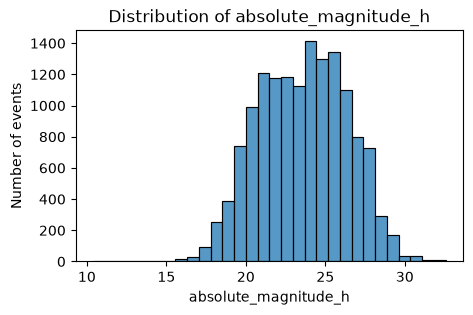

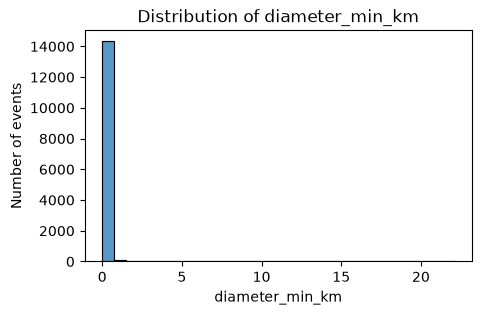

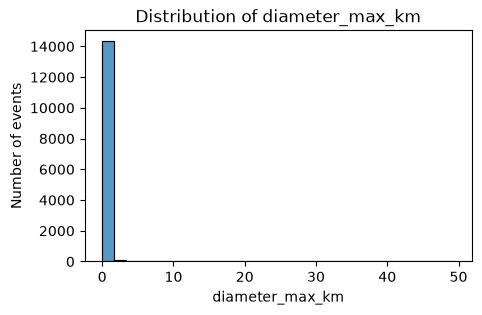

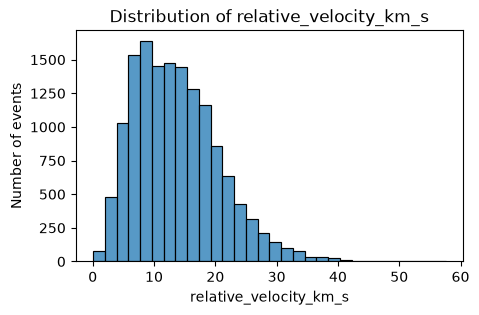

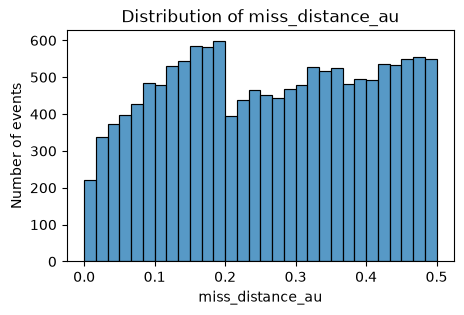

In [10]:
#histograms
for f in continuous_features:
    plt.figure(figsize=(5, 3))
    sns.histplot(data=df, x=f, bins=30)
    plt.title(f"Distribution of {f}")
    plt.xlabel(f)
    plt.ylabel("Number of events")

plt.show()


From this I observed that absolute magnitude looked normally distributed, however the diameter features had extreme right-skew. This suggested the majority of asteroids had very small diameters, but there existed a small amount of extremely large asteroids. I was interested by this as it could play a pivotal part in the anomaly detection part of the project. Additionally, it suggested to me the potential for a log transform for the diameter features. Furthermore, relative velocity appeared to also have a moderate right-skew. However, miss distance seemed to be relatively uniformly distributed. Additionally, there was a hard limit of 0.5 AU for the miss distance of asteroids in the dataset. This is just a feature of the NASA classification of a near-Earth object.

I wanted to investigate the skew further to see if transformations would be later necessary.

In [11]:
#investigating skew
df[continuous_features].skew()

absolute_magnitude_h      -0.039062
diameter_min_km           47.165060
diameter_max_km           47.165060
relative_velocity_km_s     0.800504
miss_distance_au          -0.031054
dtype: float64

Absolute magnitude was indeed not meaningufully skewed. However, the diameter features both had extremely strong right-skews: and were exactly the same. This suggested they might introduce redundancy later on in the process if they were providing the same information. The (a)symmetry of relative velocity and miss distance were also confirmed.

Then, I plotted boxplots to further understand the distributions.

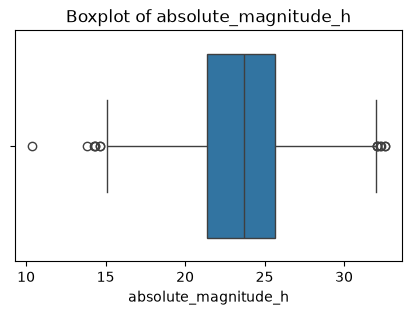

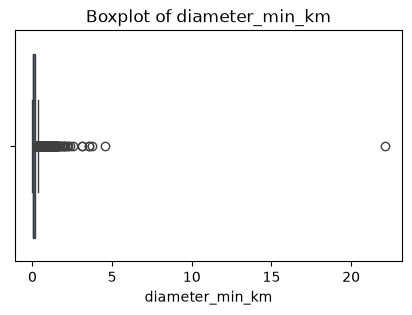

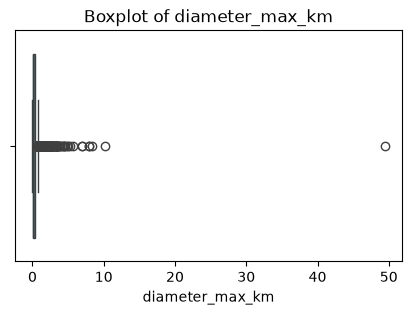

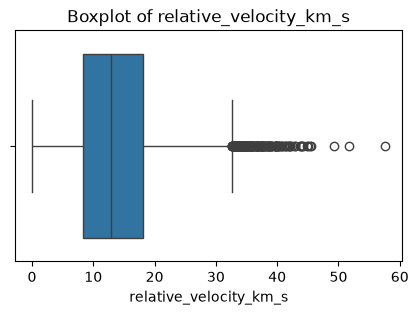

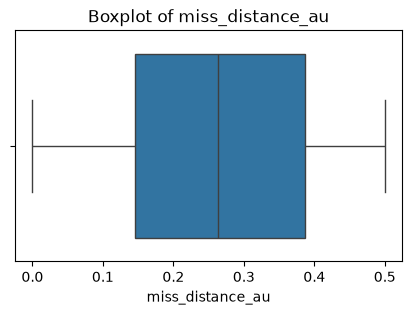

In [12]:
#boxplots
for f in continuous_features:
    plt.figure(figsize=(5,3))
    sns.boxplot(data=df, x=f)
    plt.title(f"Boxplot of {f}")
    plt.xlabel(f)

plt.show()


From this, we saw that absolute magnitude did in fact have outliers, and as absolute magnitude is inversely related to the size of the asteroid this corresponded with the extreme outliers we would see in the diameter data. For diameter min/max, many observations were found above the upper whisker as expected. With relative velocity, most observations were concentrated around the middle, with several higher-velocity outliers beyond the upper whisker, suggesting the upper tail could be relevant to risk scoring. As for miss distance, the quartiles appeared evenly distributed.

Then, I investigated the correlation between variables using a 5 x 5 correlation matrix of Pearson correlation coefficients. This would be useful for seeing how closely the data was linked, and which features were actually giving "unique" information

In [13]:
correlation_matrix = df[continuous_features].corr()
correlation_matrix

,absolute_magnitude_h,diameter_min_km,diameter_max_km,relative_velocity_km_s,miss_distance_au
absolute_magnitude_h,1.000000,-0.529624,-0.529624,-0.313995,-0.005437
diameter_min_km,-0.529624,1.000000,1.000000,0.163768,-0.026603
diameter_max_km,-0.529624,1.000000,1.000000,0.163768,-0.026603
relative_velocity_km_s,-0.313995,0.163768,0.163768,1.000000,0.279173
miss_distance_au,-0.005437,-0.026603,-0.026603,0.279173,1.000000


I made a few observations from this matrix.
1. diamter minimum and diameter maxium = 1.000, so they provide essentially the same information, so I could feature engineer the mean later.
2. absolute magnitude and diameter minimum (or maximum) = -0.530 meant a moderate negative linear relationship, and this was scientifically accurate as H is inversely related to size, but isn't linear.
3. absolute magnitude and relative velocity = -0.314, so a weak to moderate negative relationship. This meant higher absolute magnitude was associated with lower relative velocity somewhat.
4. relative velocity and miss distance = 0.279, so it yielded a weak positive correlation. 
5. miss distance and absolute magnitude = -0.005. This was interesting as it meant there was basically no linear relationship between absolute magnitude and miss distance. So, they were providing independent insights into the potential risk of an asteroid.


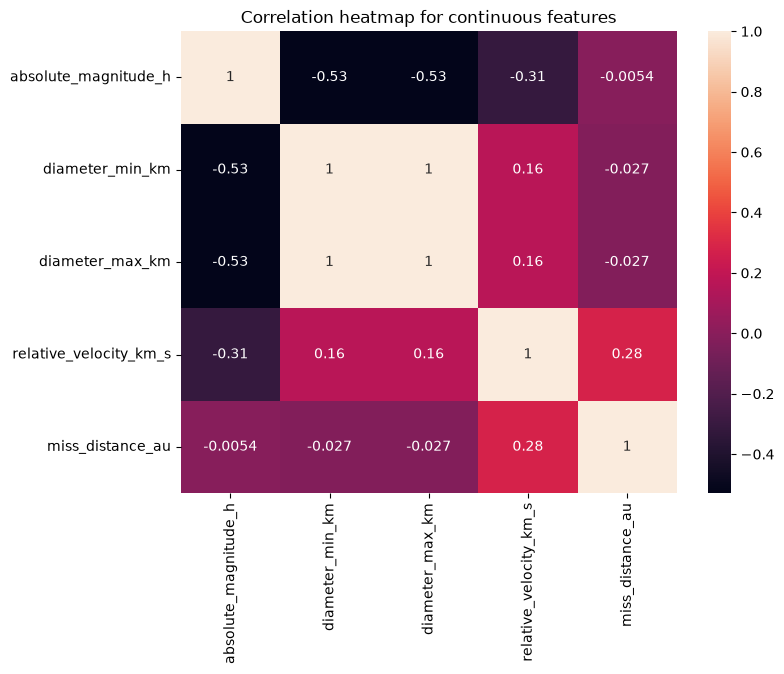

In [14]:
#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation heatmap for continuous features")
plt.show()

To better understand the relationships between variables, I plotted scatterplots. A visual representation of their relationship meant I could see if it was linear, non-linear, or truly not correlated.

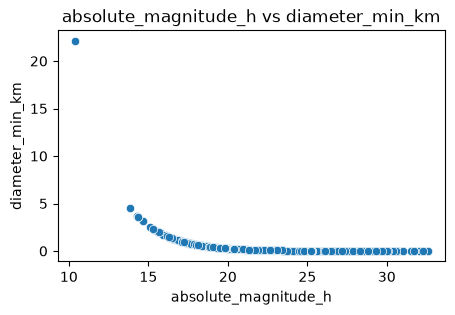

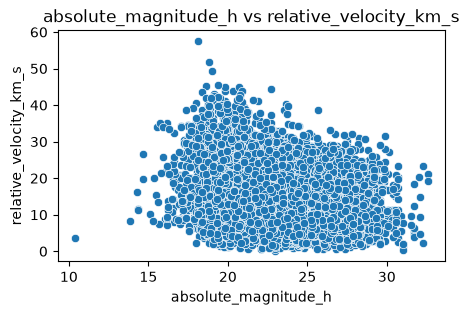

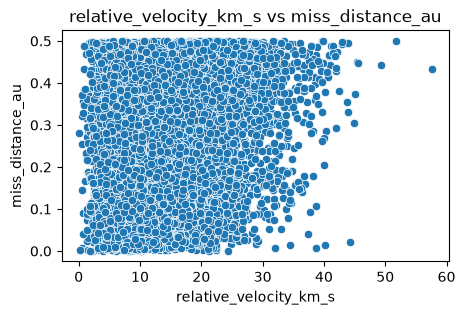

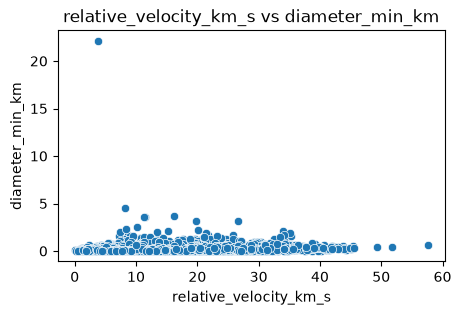

In [15]:
#want to investigate linearity of found relationships with scatterplots
relationships = [("absolute_magnitude_h", "diameter_min_km"), ("absolute_magnitude_h", "relative_velocity_km_s"), ("relative_velocity_km_s", "miss_distance_au"), ("relative_velocity_km_s", "diameter_min_km")]

for x, y in relationships:
    plt.figure(figsize=(5,3))
    sns.scatterplot(data=df,x=x,y=y)
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
plt.show()

Absolute magnitude and diameter had a strong inverse relationship. However, this is expected scientifically as the two are mathematically related. As to not introduce redundancy only one of these features would need to contribute to the risk score. Magnitude and relative velocity appeared to have no relationship at all, as the scatter plot depicted just a cloud of datapoints. Relative velocity and miss distance also showed no strong relationship, but at high velocities observations are less frequently possessing small miss distances, so this could be useful as a small miss distance obviously poses risk. Regarding relative velocity and diameter, it was hard to tell if there was any relationship, so I plotted the diameter on a log scale.


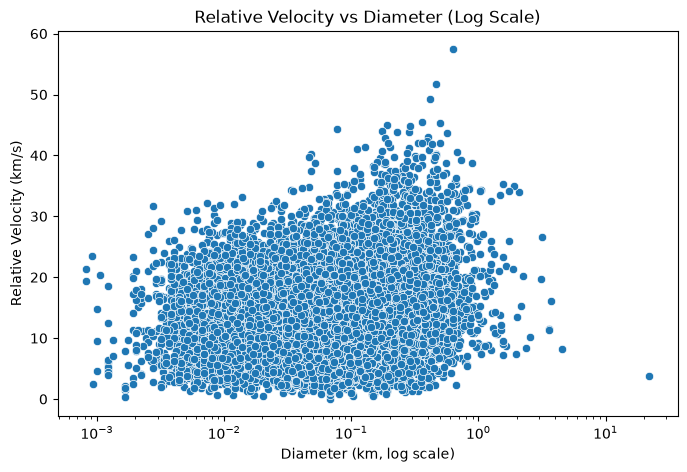

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="diameter_min_km", y="relative_velocity_km_s",)

plt.xscale("log")
plt.title("Relative Velocity vs Diameter (Log Scale)")
plt.xlabel("Diameter (km, log scale)")
plt.ylabel("Relative Velocity (km/s)")

plt.show()

Plotting a log graph revealed no apparent relationship between diameter and velocity, making sense as velocity will not depend on size.

Now, I had drawn conclusions that could be used in feature engineering for the risk score. I wanted to ensure that no redundant features were present in the equation.